### Libraries

In [2]:
import os
import numpy as np
import nibabel as nb
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import helpers
import copy
from brainspace.mesh.mesh_io import read_surface
from brainspace.mesh.array_operations import smooth_array
from brainspace.datasets import load_mask
from brainspace.plotting import plot_hemispheres
from scipy.interpolate import griddata
from scipy.stats import zscore
from scipy import stats
import scipy as sp
import pandas as pd
import seaborn as sns
import matplotlib.colors as mcolors
import utils_RRC
import matplotlib.colors as mcolors
from statsmodels.nonparametric.smoothers_lowess import lowess

### Variables

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)
# Labels and boolean mask
mask_surf = mask_5k != 0

f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

In [4]:
base = "/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0"

subjects = [
    "PNC003", "PNC006", "PNC011", "PNC018", "PNC019",
    "PNC022", "PNC024", "PNC025", "PNC026", "PNC037", "PNC038"
]

sessions = [
    "03", "03", "03", "03", "03",
    "03", "a2", "a1", "a1", "a1", "a1"
]

max_dist_all = []

for sub, ses in zip(subjects, sessions):

    gd_file = (
        f"{base}/sub-{sub}/ses-{ses}/dist/"
        f"sub-{sub}_ses-{ses}_surf-fsLR-5k_GD.shape.gii"
    )

    if not os.path.exists(gd_file):
        print(f"Missing file: {gd_file}")
        continue

    print(f"Loading {sub} ...")

    # load GIFTI
    gii = nb.load(gd_file)

    # shape.gii distance matrix는 보통 각 row가 하나의 vertex
    GD = np.vstack([d.data for d in gii.darrays])

    # vertex-wise max distance
    max_dist = np.max(GD, axis=1)

    max_dist_all.append(max_dist)

# stack subjects
max_dist_all = np.array(max_dist_all)   # shape: (n_sub, 9684)

print("Shape:", max_dist_all.shape)

# ===== group-level statistics =====

mean_max_dist = np.mean(max_dist_all, axis=0)
std_max_dist  = np.std(max_dist_all, axis=0)
ci_max_dist   = 1.96 * std_max_dist / np.sqrt(max_dist_all.shape[0])

print("Done.")

Loading PNC003 ...
Loading PNC006 ...
Loading PNC011 ...
Loading PNC018 ...
Loading PNC019 ...
Loading PNC022 ...
Loading PNC024 ...
Loading PNC025 ...
Loading PNC026 ...
Loading PNC037 ...
Loading PNC038 ...
Shape: (11, 9684)
Done.


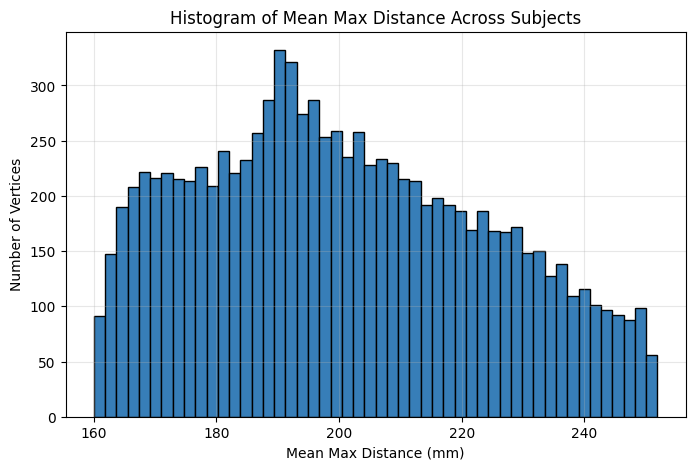

In [5]:
plt.figure(figsize=(8, 5))
plt.hist(mean_max_dist, bins=50, color="#377eb8", edgecolor="black")  # bins는 원하는 만큼 조절 가능
plt.xlabel("Mean Max Distance (mm)")   # 단위가 mm인지 확인하세요
plt.ylabel("Number of Vertices")
plt.title("Histogram of Mean Max Distance Across Subjects")
plt.grid(True, alpha=0.3)
plt.show()

### Geodesic Figure

In [3]:
time_series_lh = nb.load('/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-03/func/desc-me_task-rest_bold/surf/sub-PNC019_ses-03_hemi-L_surf-fsLR-5k.func.gii').darrays[0].data
time_series_rh = nb.load('/data/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0/sub-PNC019/ses-03/func/desc-me_task-rest_bold/surf/sub-PNC019_ses-03_hemi-R_surf-fsLR-5k.func.gii').darrays[0].data
time_series = mask_5k = np.concatenate((time_series_lh, time_series_rh), axis=0)

In [5]:
time_series_lh.shape

(4842,)